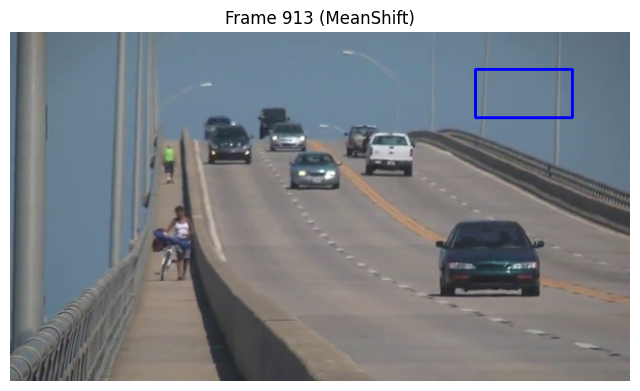

End of video / cannot read next frame.
Released video and closed figures.


In [7]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

# ----------------------------
# SETTINGS
# ----------------------------
video_path = "slow_traffic_small.mp4"   # <-- put your video file name/path here

# Initial tracking window (x, y, w, h) on the FIRST frame
x, y, w, h = 300, 200, 100, 50
track_window = (x, y, w, h)

# Stop conditions (Jupyter cannot reliably do ESC)
max_frames = 1000        # hard safety stop (set None to disable)
display_every = 1       # show every Nth frame (increase to speed up display)

# Termination criteria: (type, max_iter, epsilon)
term_crit = (cv.TERM_CRITERIA_EPS | cv.TERM_CRITERIA_COUNT, 10, 1)

# ----------------------------
# OPEN VIDEO
# ----------------------------
cap = cv.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError(f"Cannot open video: {video_path}")

ret, frame = cap.read()
if not ret:
    cap.release()
    raise RuntimeError("Could not read the first frame. Check video_path / codec.")

# ----------------------------
# ROI + HISTOGRAM (on first frame)
# ----------------------------
roi = frame[y:y+h, x:x+w]
if roi.size == 0:
    cap.release()
    raise ValueError("Initial track_window is out of frame bounds. Fix x,y,w,h.")

hsv_roi = cv.cvtColor(roi, cv.COLOR_BGR2HSV)

mask = cv.inRange(
    hsv_roi,
    np.array((0., 60., 32.)),
    np.array((180., 255., 255.))
)

roi_hist = cv.calcHist([hsv_roi], [0], mask, [180], [0, 180])
cv.normalize(roi_hist, roi_hist, 0, 255, cv.NORM_MINMAX)

# ----------------------------
# JUPYTER DISPLAY SETUP
# ----------------------------
plt.figure(figsize=(8, 5))
ax = plt.gca()
img_artist = None

def show_frame_bgr(frame_bgr, title=""):
    global img_artist
    frame_rgb = cv.cvtColor(frame_bgr, cv.COLOR_BGR2RGB)
    if img_artist is None:
        img_artist = ax.imshow(frame_rgb)
        ax.set_axis_off()
    else:
        img_artist.set_data(frame_rgb)
    ax.set_title(title)
    clear_output(wait=True)
    display(plt.gcf())

# Show first frame with initial box
init_vis = frame.copy()
x, y, w, h = track_window
cv.rectangle(init_vis, (x, y), (x+w, y+h), (255, 0, 0), 2)
show_frame_bgr(init_vis, "Frame 0 (initial window)")

# ----------------------------
# MAIN LOOP
# ----------------------------
frame_idx = 0
try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("End of video / cannot read next frame.")
            break

        hsv = cv.cvtColor(frame, cv.COLOR_BGR2HSV)

        # Backprojection of histogram onto current frame
        dst = cv.calcBackProject([hsv], [0], roi_hist, [0, 180], 1)

        # MeanShift update
        _, track_window = cv.meanShift(dst, track_window, term_crit)

        # Draw tracking window
        x, y, w, h = track_window
        out = frame.copy()
        cv.rectangle(out, (x, y), (x+w, y+h), (255, 0, 0), 2)

        frame_idx += 1

        # Inline visualization
        if display_every is not None and frame_idx % display_every == 0:
            show_frame_bgr(out, f"Frame {frame_idx} (MeanShift)")

        # Safety stop for notebooks
        if max_frames is not None and frame_idx >= max_frames:
            print(f"Stopped at max_frames={max_frames}.")
            break

except KeyboardInterrupt:
    print("Stopped by KeyboardInterrupt (Interrupt kernel / Ctrl+C).")

finally:
    cap.release()
    plt.close("all")
    print("Released video and closed figures.")
